In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\fouod\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [5]:
import os
print(os.listdir(r"C:\Users\fouod\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3"))
file_path = os.path.join(path, "creditcard.csv")
print(file_path)

['creditcard.csv']
C:\Users\fouod\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv


In [7]:
df = pd.read_csv(file_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
# 2. Aperçu du dataset
print("Dimensions du dataset :", df.shape)
print("\n--- Distribution des classes (0: Légitime, 1: Fraude) ---")
print(df['Class'].value_counts())
print("\n--- Pourcentage de fraude ---")
print(df['Class'].value_counts(normalize=True) * 100)

Dimensions du dataset : (284807, 31)

--- Distribution des classes (0: Légitime, 1: Fraude) ---
Class
0    284315
1       492
Name: count, dtype: int64

--- Pourcentage de fraude ---
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [11]:
df[df['Class']==0]['Amount'].describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [12]:
df[df['Class']==1]['Amount'].describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [13]:
df.isnull().sum().max()

0

# Étape 3 : Feature Engineering & Preprocessing

In [14]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

# 1. Normalisation des colonnes non PCA
scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# On supprime les anciennes colonnes 'Amount' et 'Time'
df_prep = df.drop(['Time', 'Amount'], axis=1)

# 2. Séparation Features (X) et Target (y)
X = df_prep.drop('Class', axis=1)
y = df_prep['Class']

# 3. Train-Test Split Stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille du jeu d'entraînement : {X_train.shape}")
print(f"Taille du jeu de test : {X_test.shape}")
print(f"Nombre de fraudes dans le jeu d'entraînement : {y_train.sum()}")
print(f"Nombre de fraudes dans le jeu de test : {y_test.sum()}")

Taille du jeu d'entraînement : (227845, 30)
Taille du jeu de test : (56962, 30)
Nombre de fraudes dans le jeu d'entraînement : 394
Nombre de fraudes dans le jeu de test : 98


# Étape 4 : Gestion du Déséquilibre & Première Modélisation

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

# Calcul du ratio de déséquilibre pour XGBoost (Négatifs / Positifs)
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

# Initialisation et entraînement du modèle
model_xgb = XGBClassifier(
    scale_pos_weight=ratio,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model_xgb.fit(X_train, y_train)

# Prédictions
y_pred = model_xgb.predict(X_test)
y_proba = model_xgb.predict_proba(X_test)[:, 1]

# Évaluation des performances
print("--- Evaluation du Modèle XGBoost ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC Score (Precision-Recall) : {average_precision_score(y_test, y_proba):.4f}")
print(f"Matrice de confusion: \n{confusion_matrix(y_test, y_pred)}")

--- Evaluation du Modèle XGBoost ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.50      0.85      0.63        98

    accuracy                           1.00     56962
   macro avg       0.75      0.92      0.81     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score : 0.9734
PR-AUC Score (Precision-Recall) : 0.8384
Matrice de confusion: 
[[56781    83]
 [   15    83]]


# Étape 5 : Explicabilité du Modèle avec SHAP (XAI - Explainable AI)

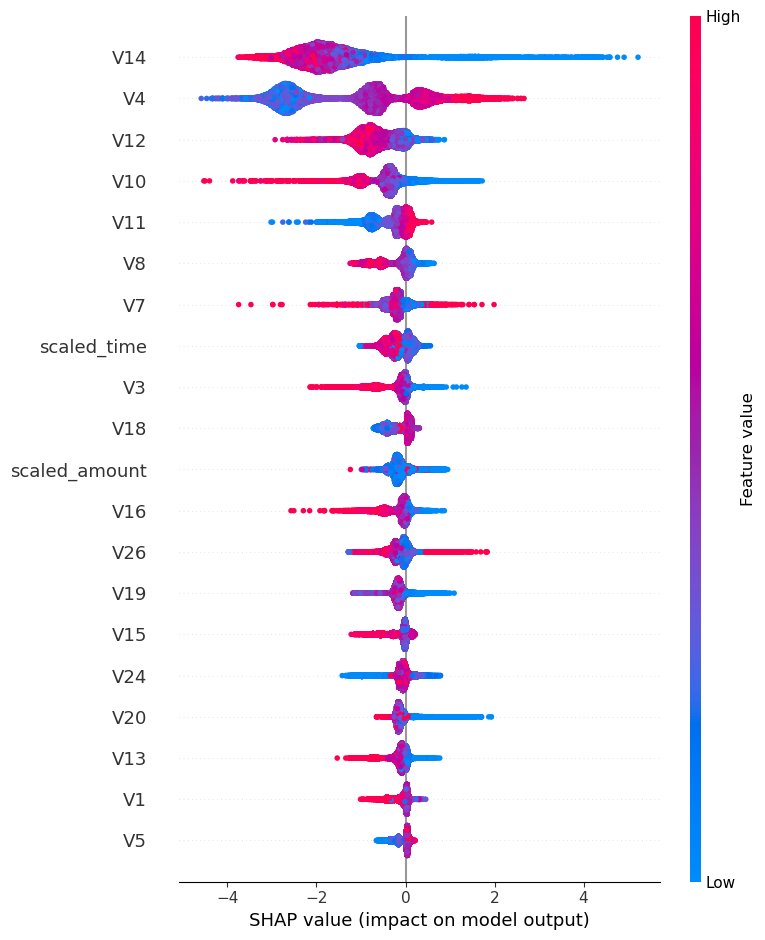

In [22]:
import shap

# 1. Création de l'explicateur SHAP spécifique à XGBoost (TreeExplainer)
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

# 2. Visualisation globale de l'importance des variables (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

# Étape 6 : Industrialisation & Déploiement

## 1. Sauvegarde du Modèle et du Scaler

In [23]:
import pickle

fraud_model_data = {
    'model': model_xgb,
    'scaler': scaler,
    'features': list(X_train.columns)
}

with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(fraud_model_data, f)

print("Modèle et Scaler sauvegardés dans 'fraud_model.pkl' !")

Modèle et Scaler sauvegardés dans 'fraud_model.pkl' !


## 2. Code de l'API FastAPI (app_fraud.py)

In [24]:
from fastapi import FastAPI
from pydantic import BaseModel
import pickle
import numpy as np
import pandas as pd

app = FastAPI(title="Credit Card Fraud Detection API")

# Chargement des artefacts
with open('fraud_model.pkl', 'rb') as f:
    data = pickle.load(f)

model = data['model']
scaler = data['scaler']
features = data['features']

class Transaction(BaseModel):
    Time: float
    Amount: float
    V1: float; V2: float; V3: float; V4: float; V5: float
    V6: float; V7: float; V8: float; V9: float; V10: float
    V11: float; V12: float; V13: float; V14: float; V15: float
    V16: float; V17: float; V18: float; V19: float; V20: float
    V21: float; V22: float; V23: float; V24: float; V25: float
    V26: float; V27: float; V28: float

@app.post("/predict")
def predict_fraud(transaction: Transaction):
    # Conversion en DataFrame
    input_data = pd.DataFrame([transaction.dict()])
    
    # Prétraitement de Time et Amount
    input_data['scaled_amount'] = scaler.transform(input_data[['Amount']].values)
    input_data['scaled_time'] = scaler.transform(input_data[['Time']].values)
    input_data = input_data.drop(['Time', 'Amount'], axis=1)
    
    # Re-ordonner les colonnes pour correspondre à l'entraînement
    input_data = input_data[features]
    
    # Prédictions
    proba = float(model.predict_proba(input_data)[0][1])
    is_fraud = bool(proba > 0.5)
    
    return {
        "fraud_prediction": is_fraud,
        "fraud_probability": round(proba, 4),
        "status": "ALERT" if is_fraud else "APPROVED"
    }

## 3. Interface Streamlit (ui_fraud.py)

In [25]:
import streamlit as st
import pickle
import pandas as pd
import numpy as np

st.set_page_config(page_title="Fraud Detection Dashboard", layout="wide")

st.title("🛡️ Système de Détection de Fraude par Carte Bancaire")
st.write("Évaluation du risque de transaction en temps réel avec explicabilité.")

@st.cache_resource
def load_assets():
    with open('fraud_model.pkl', 'rb') as f:
        return pickle.load(f)

assets = load_assets()
model = assets['model']
scaler = assets['scaler']
features = assets['features']

st.subheader("Simulateur de Transaction")
col1, col2 = st.columns(2)

with col1:
    amount = st.number_input("Montant de la transaction ($)", min_value=0.0, value=149.99)
with col2:
    time_val = st.number_input("Temps (secondes écoulées)", min_value=0.0, value=406.0)

st.write("Seuil de détection configuré : **0.50**")

if st.button("Analyser la transaction"):
    # Construction d'un vecteur d'entrée factice (exemple de test)
    sample_vector = np.zeros((1, len(features)))
    df_sample = pd.DataFrame(sample_vector, columns=features)
    
    # Injection du montant et temps transformés
    df_sample['scaled_amount'] = scaler.transform([[amount]])
    df_sample['scaled_time'] = scaler.transform([[time_val]])
    
    proba = model.predict_proba(df_sample)[0][1]
    
    if proba >= 0.5:
        st.error(f"🚨 ALERTE FRAUDE DÉTECTÉE | Probabilité : {proba:.2%}")
    else:
        st.success(f"✅ TRANSACTION APPROUVÉE | Probabilité de fraude : {proba:.2%}")

2026-08-27 05:47:00.630 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 05:47:00.633 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 05:47:01.988 
  command:

    streamlit run C:\Users\fouod\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-08-27 05:47:01.989 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 05:47:01.992 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 05:47:01.993 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 05:47:02.002 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn